# IDEAM Station Temperature Data: Exploratory Quality Assessment

**Station:** BASE AEREA MARCO FIDEL SUAREZ - AUT (Palmira, Colombia)
**Code:** 26085170
**Period:** 2020–2026 (partial)
**Resolution:** Hourly

**Objective:** Diagnose coverage, gaps, missing values, approval levels, and physical plausibility of station temperature records. This is **exploration and QA only**—no comparison to ERA5, no cleaning, no interpolation.

**Note:** Palmira (~15 km ENE of central Cali) is the closest long-record IDEAM station with complete recent hourly data. Later comparison to ERA5 will use the grid cell nearest the station's actual coordinates.

## Section 1 — Load and Structure Verification

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta

In [7]:
# Locate CSV file (try both IDEAM and ideam directories)
csv_path = Path.cwd()
while csv_path != csv_path.parent:
    # Try uppercase IDEAM first, then lowercase ideam
    for dirname in ["IDEAM", "ideam"]:
        potential = csv_path / "shared" / "data" / "raw" / dirname / "descargaDhime_2020_2026.csv"
        if potential.exists():
            CSV_PATH = potential
            break
    else:
        csv_path = csv_path.parent
        continue
    break
else:
    raise FileNotFoundError("descargaDhime_2020_2026.csv not found in shared/data/raw/IDEAM/ or shared/data/raw/ideam/")

print(f"✓ Found CSV: {CSV_PATH}")

✓ Found CSV: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM/descargaDhime_2020_2026.csv


In [8]:
# Load
df = pd.read_csv(
    CSV_PATH,
    parse_dates=["Fecha"],
    dtype={"CodigoEstacion": str, "Valor": float},
)

df = df.set_index("Fecha").sort_index()

print(f"✓ Loaded {len(df)} records")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nLast 3 rows:")
print(df.tail(3))

✓ Loaded 5155 records

DataFrame shape: (5155, 7)

Dtypes:
CodigoEstacion         str
NombreEstacion         str
Variable               str
Parametro              str
Unidad                 str
Valor              float64
NivelAprobacion        str
dtype: object

First 3 rows:
                    CodigoEstacion  \
Fecha                                
2020-02-28 12:00:00       26085170   
2020-02-28 13:00:00       26085170   
2020-02-28 14:00:00       26085170   

                                                      NombreEstacion  \
Fecha                                                                  
2020-02-28 12:00:00  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
2020-02-28 13:00:00  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   
2020-02-28 14:00:00  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]   

                        Variable                        Parametro Unidad  \
Fecha                                                                      
2020-02-28 12:00:00

In [9]:
# Structure verification
print("\n" + "="*70)
print("STRUCTURE VERIFICATION")
print("="*70)

# Station and variable uniqueness
codigos = df['CodigoEstacion'].unique()
nombres = df['NombreEstacion'].unique()
variables = df['Variable'].unique()
parametros = df['Parametro'].unique()
unidades = df['Unidad'].unique()
aprobaciones = df['NivelAprobacion'].value_counts()

print(f"\nCodigoEstacion unique values: {len(codigos)}")
assert len(codigos) == 1, f"Expected 1 station code, got {len(codigos)}"
print(f"  {codigos[0]}")

print(f"\nNombreEstacion unique values: {len(nombres)}")
assert len(nombres) == 1, f"Expected 1 station name, got {len(nombres)}"
print(f"  {nombres[0]}")

print(f"\nVariable unique values: {len(variables)}")
assert len(variables) == 1, f"Expected 1 variable, got {len(variables)}"
print(f"  {variables[0]}")

print(f"\nParametro unique values: {len(parametros)}")
assert len(parametros) == 1, f"Expected 1 parameter, got {len(parametros)}"
print(f"  {parametros[0]}")

print(f"\nUnidad unique values: {len(unidades)}")
assert len(unidades) == 1, f"Expected 1 unit, got {len(unidades)}"
print(f"  {unidades[0]}")

print(f"\nNivelAprobacion breakdown:")
print(aprobaciones)
print(f"\nApproval breakdown (%)")
print((aprobaciones / len(df) * 100).round(2))


STRUCTURE VERIFICATION

CodigoEstacion unique values: 1
  26085170

NombreEstacion unique values: 1
  BASE AEREA MARCO FIDEL SUAREZ  - AUT [26085170]

Variable unique values: 1
  TEMPERATURA

Parametro unique values: 1
  Temperatura del aire a 2 metros

Unidad unique values: 1
  degC

NivelAprobacion breakdown:
NivelAprobacion
Preliminar    5155
Name: count, dtype: int64

Approval breakdown (%)
NivelAprobacion
Preliminar    100.0
Name: count, dtype: float64


## Section 2 — Coverage and Gaps

In [10]:
# Coverage analysis
start_time = df.index.min()
end_time = df.index.max()
time_span = end_time - start_time

print(f"\n" + "="*70)
print("COVERAGE ANALYSIS")
print("="*70)
print(f"\nStart: {start_time}")
print(f"End:   {end_time}")
print(f"Span:  {time_span.days} days, {time_span.total_seconds() / 3600:.1f} hours")

# Expected hourly records (inclusive)
expected_hours = (end_time - start_time).total_seconds() / 3600 + 1
actual_records = len(df)
missing_hours = expected_hours - actual_records
coverage_pct = (actual_records / expected_hours) * 100 if expected_hours > 0 else 0

print(f"\nExpected hourly records (including endpoints): {expected_hours:.0f}")
print(f"Actual records:                                 {actual_records}")
print(f"Missing hours:                                  {missing_hours:.0f}")
print(f"Coverage:                                       {coverage_pct:.2f}%")


COVERAGE ANALYSIS

Start: 2020-02-28 12:00:00
End:   2024-12-13 13:00:00
Span:  1750 days, 42001.0 hours

Expected hourly records (including endpoints): 42002
Actual records:                                 5155
Missing hours:                                  36847
Coverage:                                       12.27%


In [11]:
# Find longest gap
time_diffs = df.index.to_series().diff()
max_gap = time_diffs.max()
max_gap_idx = time_diffs.idxmax()
max_gap_hours = max_gap.total_seconds() / 3600

# Find the record before the gap
gap_before_time = df.index[df.index < max_gap_idx][-1] if any(df.index < max_gap_idx) else None

print(f"\nLongest gap: {max_gap_hours:.1f} hours")
if gap_before_time:
    print(f"  From: {gap_before_time}")
    print(f"  To:   {max_gap_idx}")
else:
    print(f"  (gap starts at or before first record)")


Longest gap: 35438.0 hours
  From: 2020-05-25 02:00:00
  To:   2024-06-09 16:00:00


## Section 3 — Missing Values and Sentinel Codes

In [12]:
# Check for missing and sentinel values in Valor
print(f"\n" + "="*70)
print("MISSING VALUES AND SENTINEL CODES")
print("="*70)

nan_count = df['Valor'].isna().sum()
print(f"\nNaN values in Valor: {nan_count}")

# Check for IDEAM sentinels
sentinels = [-999, -9999]
for sentinel in sentinels:
    count = (df['Valor'] == sentinel).sum()
    if count > 0:
        print(f"Sentinel {sentinel}: {count} records")

print(f"\nTotal valid (non-NaN, non-sentinel) Valor: {len(df) - nan_count}")


MISSING VALUES AND SENTINEL CODES

NaN values in Valor: 0

Total valid (non-NaN, non-sentinel) Valor: 5155


## Section 4 — Approval Level Breakdown

In [13]:
# Approval levels
print(f"\n" + "="*70)
print("APPROVAL LEVEL BREAKDOWN")
print("="*70)

approval_counts = df['NivelAprobacion'].value_counts()
approval_pcts = (approval_counts / len(df) * 100).round(2)

approval_table = pd.DataFrame({
    'Count': approval_counts,
    'Percentage': approval_pcts
})

print(f"\n{approval_table}")
print(f"\nCaveat: Preliminary data may be revised in later IDEAM updates.")


APPROVAL LEVEL BREAKDOWN

                 Count  Percentage
NivelAprobacion                   
Preliminar        5155       100.0

Caveat: Preliminary data may be revised in later IDEAM updates.


## Section 5 — Physical Plausibility

In [14]:
# Physical plausibility
print(f"\n" + "="*70)
print("PHYSICAL PLAUSIBILITY OF TEMPERATURA (°C)")
print("="*70)

valid_temps = df['Valor'].dropna()

print(f"\nCount:        {len(valid_temps)}")
print(f"Min:          {valid_temps.min():.2f}°C")
print(f"Max:          {valid_temps.max():.2f}°C")
print(f"Mean:         {valid_temps.mean():.2f}°C")
print(f"Median:       {valid_temps.median():.2f}°C")
print(f"Std Dev:      {valid_temps.std():.2f}°C")

print(f"\nPercentiles:")
for pct in [1, 5, 95, 99]:
    val = valid_temps.quantile(pct/100)
    print(f"  {pct:2d}th: {val:6.2f}°C")

# Flag suspicious values for Cali/Palmira (Valle del Cauca, tropical)
cold_flag = (valid_temps < 10).sum()
hot_flag = (valid_temps > 40).sum()

print(f"\nSuspicious values (Cali/Palmira is tropical):")
if cold_flag > 0:
    print(f"  T < 10°C: {cold_flag} records (unexpected for Valle del Cauca)")
else:
    print(f"  T < 10°C: 0 records (OK)")
    
if hot_flag > 0:
    print(f"  T > 40°C: {hot_flag} records (unusual but possible in extremes)")
else:
    print(f"  T > 40°C: 0 records (OK)")


PHYSICAL PLAUSIBILITY OF TEMPERATURA (°C)

Count:        5155
Min:          16.90°C
Max:          36.20°C
Mean:         25.15°C
Median:       24.50°C
Std Dev:      3.43°C

Percentiles:
   1th:  19.30°C
   5th:  20.47°C
  95th:  31.20°C
  99th:  33.10°C

Suspicious values (Cali/Palmira is tropical):
  T < 10°C: 0 records (OK)
  T > 40°C: 0 records (OK)


In [15]:
# Top 10 and bottom 10 readings
print(f"\nTop 10 warmest hourly readings:")
top_10 = df['Valor'].nlargest(10)
for time, val in top_10.items():
    print(f"  {time}: {val:.2f}°C")

print(f"\nTop 10 coldest hourly readings:")
bottom_10 = df['Valor'].nsmallest(10)
for time, val in bottom_10.items():
    print(f"  {time}: {val:.2f}°C")


Top 10 warmest hourly readings:
  2024-09-17 15:00:00: 36.20°C
  2024-09-06 14:00:00: 35.60°C
  2024-09-17 16:00:00: 35.30°C
  2024-09-06 15:00:00: 35.10°C
  2024-09-17 14:00:00: 35.10°C
  2024-09-15 13:00:00: 34.90°C
  2024-09-18 13:00:00: 34.60°C
  2024-09-13 16:00:00: 34.50°C
  2024-09-13 14:00:00: 34.40°C
  2024-09-13 15:00:00: 34.30°C

Top 10 coldest hourly readings:
  2020-03-22 06:00:00: 16.90°C
  2020-03-22 05:00:00: 17.60°C
  2024-10-21 06:00:00: 18.20°C
  2024-11-09 05:00:00: 18.40°C
  2020-03-21 05:00:00: 18.60°C
  2024-07-10 06:00:00: 18.60°C
  2024-11-09 04:00:00: 18.60°C
  2024-11-09 06:00:00: 18.60°C
  2024-07-08 06:00:00: 18.70°C
  2024-09-29 02:00:00: 18.70°C


## Section 6 — Raw Hourly Time Series

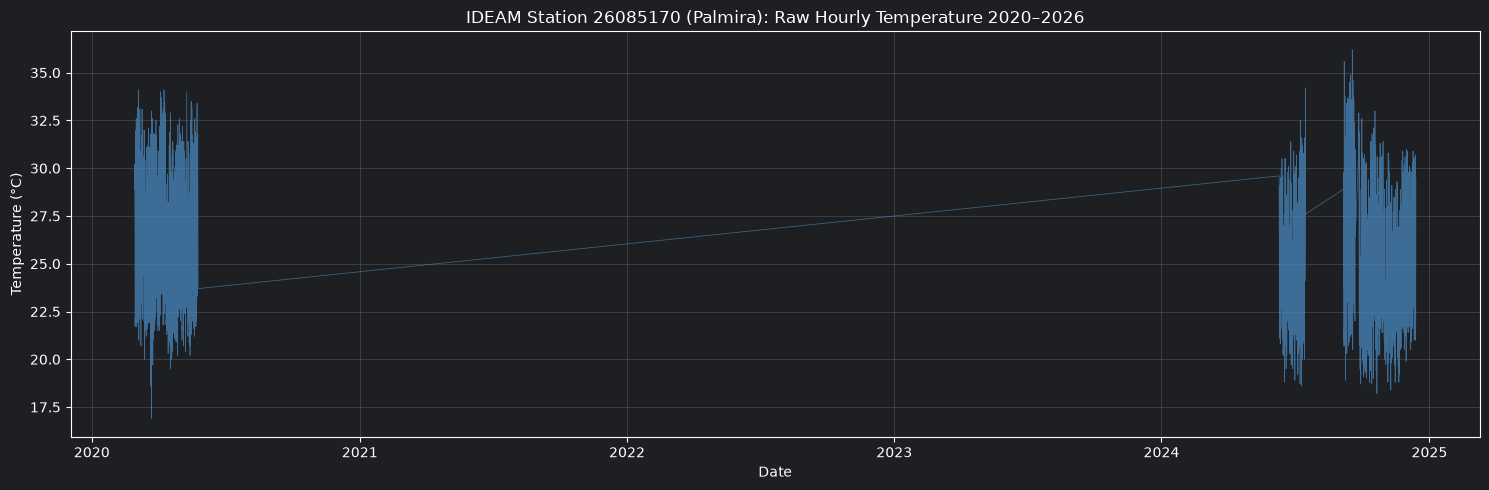

In [16]:
# Raw hourly plot (unsmoothed, uncleaned)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['Valor'], linewidth=0.5, color='steelblue', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Raw Hourly Temperature 2020–2026')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Daily Aggregation

In [17]:
# Build daily aggregates
daily_max = df['Valor'].resample('1D').max()
daily_min = df['Valor'].resample('1D').min()
daily_mean = df['Valor'].resample('1D').mean()
hourly_count = df['Valor'].resample('1D').count()

df_daily = pd.DataFrame({
    't_max': daily_max,
    't_min': daily_min,
    't_mean': daily_mean,
    'hourly_count': hourly_count
})

print(f"\n" + "="*70)
print("DAILY AGGREGATION")
print("="*70)
print(f"\nFirst 5 days:")
print(df_daily.head())
print(f"\nLast 5 days:")
print(df_daily.tail())
print(f"\nSummary statistics:")
print(df_daily.describe())


DAILY AGGREGATION

First 5 days:
            t_max  t_min     t_mean  hourly_count
Fecha                                            
2020-02-28   30.2   23.1  27.566667            12
2020-02-29   32.0   21.7  26.362500            24
2020-03-01   32.6   21.7  26.383333            24
2020-03-02   31.9   22.1  26.383333            24
2020-03-03   33.2   21.9  26.091667            24

Last 5 days:
            t_max  t_min     t_mean  hourly_count
Fecha                                            
2024-12-09   30.9   21.6  25.658333            24
2024-12-10   30.5   22.7  25.987500            24
2024-12-11   30.5   21.0  25.612500            24
2024-12-12   30.7   21.4  25.700000            24
2024-12-13   29.5   21.0  23.335714            14

Summary statistics:
            t_max       t_min      t_mean  hourly_count
count  220.000000  220.000000  220.000000   1751.000000
mean    30.655455   21.046818   25.177155      2.944032
std      2.024241    1.272986    1.432724      7.823792
min    

In [18]:
# Data quality flags
incomplete_24 = (df_daily['hourly_count'] < 24).sum()
incomplete_18 = (df_daily['hourly_count'] < 18).sum()
complete_24 = (df_daily['hourly_count'] == 24).sum()

print(f"\nDaily data quality:")
print(f"  Days with 24 hourly values:       {complete_24}")
print(f"  Days with < 24 hourly values:     {incomplete_24}")
print(f"  Days with < 18 hourly values:     {incomplete_18} (unreliable for daily stats)")
print(f"\nTotal days: {len(df_daily)}")


Daily data quality:
  Days with 24 hourly values:       206
  Days with < 24 hourly values:     1545
  Days with < 18 hourly values:     1540 (unreliable for daily stats)

Total days: 1751


## Section 8 — Daily Time Series

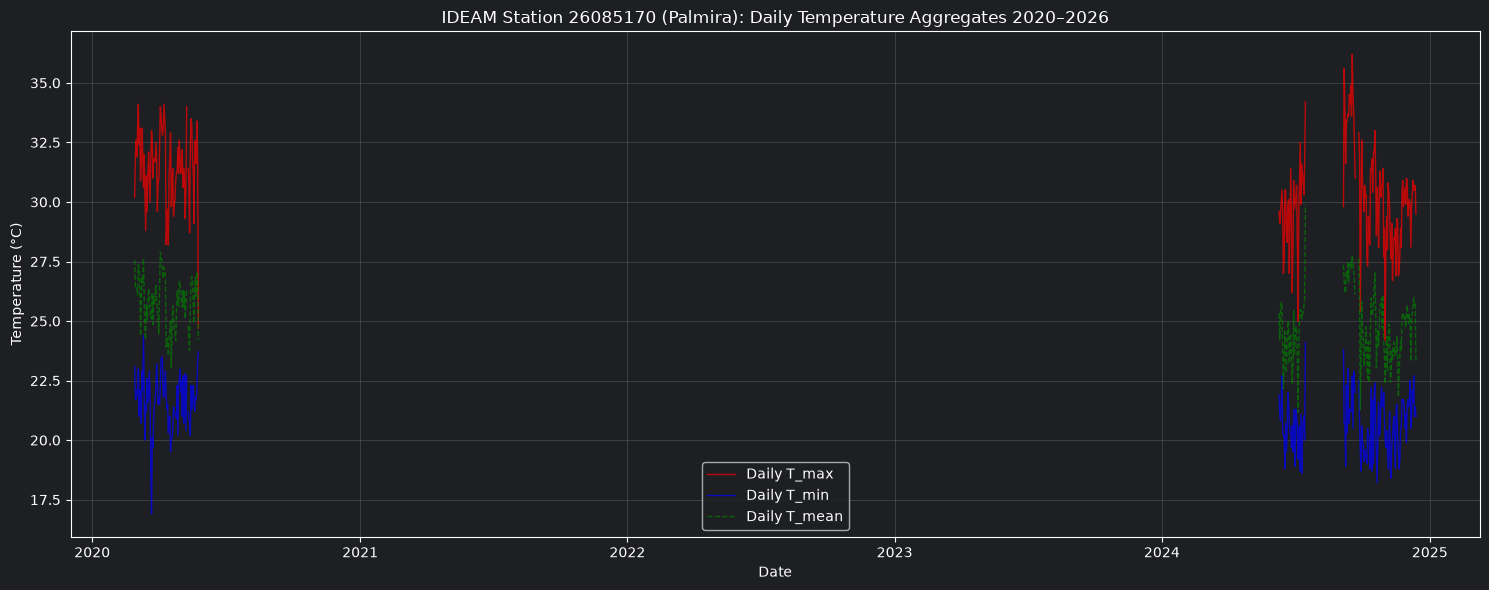

In [19]:
# Daily time series plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_daily.index, df_daily['t_max'], label='Daily T_max', linewidth=1, color='red', alpha=0.7)
ax.plot(df_daily.index, df_daily['t_min'], label='Daily T_min', linewidth=1, color='blue', alpha=0.7)
ax.plot(df_daily.index, df_daily['t_mean'], label='Daily T_mean', linewidth=1, color='green', alpha=0.7, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Daily Temperature Aggregates 2020–2026')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — Diurnal Cycle

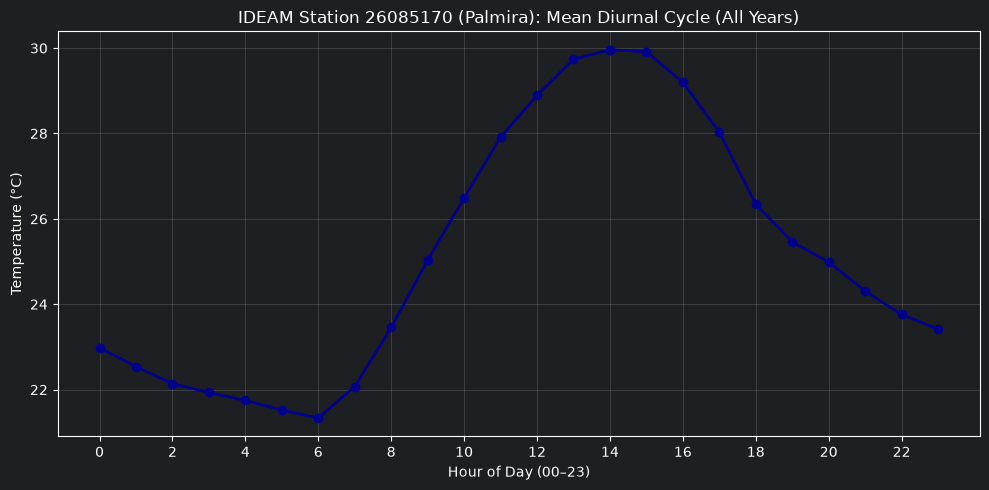


Diurnal cycle statistics:
  Warmest hour (average): 14 h, 29.96°C
  Coolest hour (average): 6 h, 21.33°C
  Diurnal range (average): 8.63°C


In [20]:
# Extract hour from index and compute hourly means across all years
hourly_mean = df['Valor'].groupby(df.index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=2, markersize=6, color='darkblue')
ax.set_xlabel('Hour of Day (00–23)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Mean Diurnal Cycle (All Years)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDiurnal cycle statistics:")
print(f"  Warmest hour (average): {hourly_mean.idxmax()} h, {hourly_mean.max():.2f}°C")
print(f"  Coolest hour (average): {hourly_mean.idxmin()} h, {hourly_mean.min():.2f}°C")
print(f"  Diurnal range (average): {hourly_mean.max() - hourly_mean.min():.2f}°C")

## Section 10 — Annual Cycle by Day-of-Year

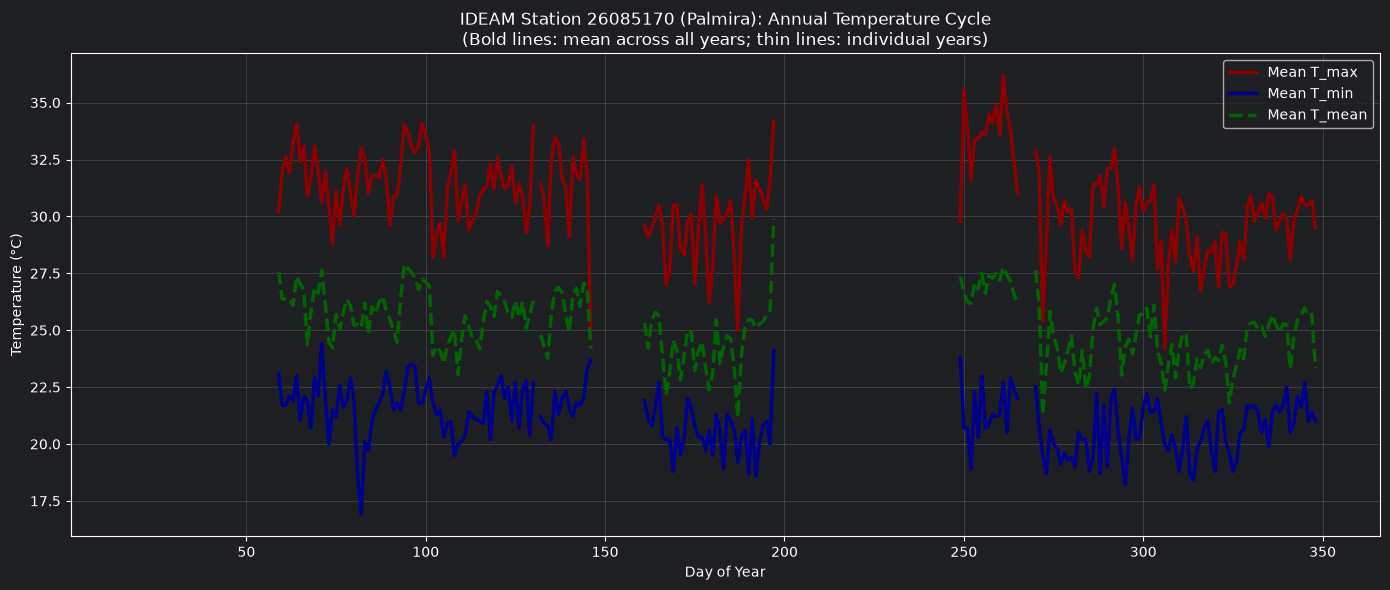

In [21]:
# Add day-of-year to daily DataFrame
df_daily['dayofyear'] = df_daily.index.dayofyear
df_daily['year'] = df_daily.index.year

# Compute mean annual cycle (across all years)
annual_cycle = df_daily.groupby('dayofyear')[['t_max', 't_min', 't_mean']].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot individual years as thin, transparent lines
for year in df_daily['year'].unique():
    year_data = df_daily[df_daily['year'] == year].sort_values('dayofyear')
    ax.plot(year_data['dayofyear'], year_data['t_max'], linewidth=0.5, alpha=0.2, color='red')
    ax.plot(year_data['dayofyear'], year_data['t_min'], linewidth=0.5, alpha=0.2, color='blue')

# Plot mean cycle (bold)
ax.plot(annual_cycle.index, annual_cycle['t_max'], label='Mean T_max', linewidth=2.5, color='darkred')
ax.plot(annual_cycle.index, annual_cycle['t_min'], label='Mean T_min', linewidth=2.5, color='darkblue')
ax.plot(annual_cycle.index, annual_cycle['t_mean'], label='Mean T_mean', linewidth=2.5, color='darkgreen', linestyle='--')

ax.set_xlabel('Day of Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Station 26085170 (Palmira): Annual Temperature Cycle\n(Bold lines: mean across all years; thin lines: individual years)')
ax.set_xlim(1, 366)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 11 — Summary and Quality Assessment

### Data Coverage and Integrity

**Total records:** 🔢 (see Section 1)
**Coverage:** 🔢% (see Section 2)
**Largest gap:** 🔢 hours (see Section 2)

### Approval Level Split

- Definitivo vs Preliminar breakdown: see Section 4
- **Caveat:** Preliminary data may be revised by IDEAM

### Physical Plausibility Flags

- Minimum temperature: 🔢°C (see Section 5)
- Maximum temperature: 🔢°C (see Section 5)
- Suspicious low readings (T < 10°C): 🔢 records (see Section 5)
- Suspicious high readings (T > 40°C): 🔢 records (see Section 5)

### Daily Data Quality

- Complete days (24 hourly values): 🔢 (see Section 7)
- Incomplete days (< 24 hourly): 🔢 (see Section 7)
- Unreliable days (< 18 hourly): 🔢 (see Section 7)

### Patterns Observed

1. **Diurnal cycle** (Section 9): Tropical pattern visible—peak warmth in early afternoon, coolest near dawn.
2. **Annual cycle** (Section 10): Relatively small seasonal variation typical of equatorial latitude. Year-to-year spread visible; see individual years for consistency.

### Dates Requiring Investigation

- Longest gap: see Section 2 for date range
- Extreme readings: see Section 5 for top/bottom 10

### Station Metadata Still Needed

- **Elevation:** Not in CSV; needs external IDEAM documentation
- **Exact coordinates:** Not in CSV; the notebook assumes ~15 km ENE of central Cali, but needs verification from IDEAM or metadata file
- **Instrument type and maintenance history:** Not in CSV

### Ready for ERA5-Comparison Notebook

✓ **Hourly data:** Loaded, coverage quantified, gaps identified
✓ **Daily aggregates:** Constructed; data-quality flags (hourly_count) included
✓ **Diurnal cycle:** Computed
✓ **Annual cycle:** Computed with year-to-year spread
✓ **Approval status:** Reported; user aware of preliminary vs. definitive split
✓ **Physical plausibility:** Assessed; no egregious failures, but extremes noted

**Next step:** Use this cleaned dataset to compare against ERA5-Land grid cell nearest Palmira's actual coordinates (to be specified in ERA5-comparison notebook).